# Zadanie 4: obliczenia ewolucyjne

Termin realizacji: 4 maja 2026

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład "iterative method" z notatnika `tsp_lazy_constraints.ipynb` tak, aby rozwiązywał [problem podróżującego konsumenta](https://en.wikipedia.org/wiki/Traveling_purchaser_problem). Przykładowe problemy generuje poniższa funkcja `generate_random_tpp`. Przyjmij, że wszystkie miasta muszą być odwiedzone niezależnie od tego czy dokonany tam będzie zakup czy też nie. W rozwiązaniu wypisz w którym mieście kupione będą poszczególne przedmioty oraz narysuj trasę.
2. Zmodyfikuj analogicznie kod z notatnika `tsp-genetic.ipynb` tak aby rozwiązywał ten sam problem. Porównaj wydajność (czas obliczeń i wartość funkcji kosztu) dla dziewięciu losowych problemów, po trzy dla rozmiarów (n=50, k=20), (n=50, k=50) oraz (n=100, k=100). Dobierz parametry algorytmu genetycznego tak, aby czas działania nie przekraczał w żadnym przypadku minuty.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do problemu wagę przedmiotów, powiększającą koszt rozwiązania o długość trasy od miejsca zakupu do końca trasy pomnożoną przez wagę przedmiotu i stały współczynnik dobrany tak, aby dla przedmiotu średniej wagi jego transport między najbardziej odległymi miastami (w linii prostej) wynosił około 1% ceny. Nie dodawaj tego składnika do funkcji kosztu zaimplementowanej w JuMP, ale uwzględnij go w algorytmie genetycznym. Porównaj jakość rozwiązań uzyskanych przez oba algorytmy z uwzględnieniem wagi i bez.
3. Zaimplementuj dodatkowo [krzyżowanie PMX](https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Partially_mapped_crossover_(PMX)) i porównaj wydajność z tym opartym o inwersję permutacji.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zmodyfikuj problem tak, aby konsument nie musiał odwiedzać miast w których niczego nie kupuje.
3. Dodaj dodatkowo do porównania zmodyfikowany dla problemu podróżującego konsumenta przykład "lazy constraints" z notatnika `tsp_lazy_constraints.ipynb`. Dane do problemu powinny być generowane tak, aby konsument w zwracanym rozwiązaniu odwiedzał przynajmniej 3 miasta i omijał przynajmniej 2.


In [1]:
# # Instalacja pakietów (uruchom raz)
# import Pkg
# Pkg.add(["JuMP", "GLPK", "Plots"])
# Pkg.add(name="Evolutionary", version="0.11.0")  # nowsze API z time_limit, tournament

In [2]:
using JuMP
import GLPK
using Random
import Plots
using Evolutionary
using Printf
using Statistics

function generate_random_tpp(n, k; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    # macierz odległości
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]
    # cena przedmiotu k w mieście c — równomiernie w [50, 150]
    cost_item_city = 50 .+ 100 .* rand(rng, k, n)
    return X, Y, d, cost_item_city
end

# mała instancja demonstracyjna
n_demo, k_demo = 20, 10
X_demo, Y_demo, d_demo, ci_demo = generate_random_tpp(n_demo, k_demo; random_seed=42)
println("Demo: n=$(n_demo) miast, k=$(k_demo) przedmiotów")

Demo: n=20 miast, k=10 przedmiotów


## Zadanie na 3.0 — sformułowanie problemu

W problemie podróżującego konsumenta (TPP) szukamy najkrótszej trasy odwiedzającej wszystkie miasta, a dodatkowo dla każdego z $k$ przedmiotów wybieramy miasto, w którym go kupimy. Funkcja kosztu to suma długości trasy oraz cen wybranych zakupów:

$$
\min \; \sum_{i<j} d_{ij}\,x_{ij} \;+\; \sum_{p=1}^{k} \sum_{c=1}^{n} \text{cena}_{p,c}\,y_{p,c}
$$

przy ograniczeniach
- $\sum_j x_{ij}=2 \;\;\forall i$ (każde miasto ma stopień 2 w cyklu),
- $x_{ii}=0$,
- $\sum_c y_{p,c}=1 \;\;\forall p$ (każdy przedmiot kupiony dokładnie raz),
- $y_{p,c}\in\{0,1\}$, $x_{ij}\in\{0,1\}$ symetryczne,
- ograniczenia eliminujące podcykle (dodawane iteracyjnie).

Ponieważ wszystkie miasta są odwiedzane, decyzja `y` nie zależy od `x` — w optimum dla każdego przedmiotu wybierane jest miasto z najniższą ceną. Mimo to formułujemy oba zbiory zmiennych w JuMP, żeby zachować strukturę uogólnialną na zadania 4.0/5.0.

In [3]:
# funkcje pomocnicze identyczne jak w tsp_lazy_constraints.ipynb
function subtour(edges::Vector{Tuple{Int,Int}}, n)
    shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
    while !isempty(unvisited)
        this_cycle, neighbors = Int[], unvisited
        while !isempty(neighbors)
            current = pop!(neighbors)
            push!(this_cycle, current)
            if length(this_cycle) > 1
                pop!(unvisited, current)
            end
            neighbors = [j for (i, j) in edges if i == current && j in unvisited]
        end
        if length(this_cycle) < length(shortest_subtour)
            shortest_subtour = this_cycle
        end
    end
    return shortest_subtour
end

function selected_edges(x::AbstractMatrix, n)
    return Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if x[i, j] > 0.5]
end

subtour(x::Matrix{Float64}) = subtour(selected_edges(x, size(x, 1)), size(x, 1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(JuMP.value.(x))

subtour (generic function with 3 methods)

In [4]:
# Model JuMP dla TPP z odwiedzaniem wszystkich miast
function build_tpp_model_visit_all(d, cost_item_city)
    n = size(d, 1)
    K = size(cost_item_city, 1)
    model = Model(GLPK.Optimizer)
    @variable(model, x[1:n, 1:n], Bin, Symmetric)        # krawędzie cyklu
    @variable(model, y[1:K, 1:n], Bin)                   # zakupy
    @objective(model, Min,
        sum(d .* x) / 2 +
        sum(cost_item_city[p, c] * y[p, c] for p in 1:K, c in 1:n)
    )
    @constraint(model, [i in 1:n], sum(x[i, :]) == 2)
    @constraint(model, [i in 1:n], x[i, i] == 0)
    @constraint(model, [p in 1:K], sum(y[p, :]) == 1)    # każdy przedmiot kupiony raz
    return model
end

# Rozwiązanie metodą iteracyjną z opcjonalnym budżetem czasowym.
# Dla dużych instancji (np. n=100) GLPK może nie udowodnić optymalności w
# rozsądnym czasie; `total_budget` ogranicza łączny czas wszystkich wywołań
# `optimize!` w pętli. Zwracamy `status`:
#   :optimal — pełny cykl Hamiltona, dowiedzione optimum,
#   :feasible_suboptimal — pełny cykl Hamiltona, ale przerwano przed dowodem,
#   :timeout — nie udało się wyeliminować wszystkich podcykli w budżecie.
function solve_tpp_iterative(d, cost_item_city; verbose=false, total_budget=Inf)
    n = size(d, 1)
    model = build_tpp_model_visit_all(d, cost_item_city)
    set_silent(model)
    if isfinite(total_budget)
        set_time_limit_sec(model, total_budget)
    end
    optimize!(model)
    elapsed = solve_time(model)
    if !has_values(model)
        return model, elapsed, 0, :timeout
    end
    cyc = subtour(model[:x])
    iters = 0
    status = (termination_status(model) == MOI.OPTIMAL) ? :optimal : :feasible_suboptimal
    while 1 < length(cyc) < n
        if elapsed >= total_budget
            return model, elapsed, iters, :timeout
        end
        iters += 1
        verbose && println("Iter $(iters): wykryto podcykl długości $(length(cyc))")
        S = [(i, j) for (i, j) in Iterators.product(cyc, cyc) if i < j]
        @constraint(model,
            sum(model[:x][i, j] for (i, j) in S) <= length(cyc) - 1)
        if isfinite(total_budget)
            set_time_limit_sec(model, max(total_budget - elapsed, 1.0))
        end
        optimize!(model)
        elapsed += solve_time(model)
        if !has_values(model)
            return model, elapsed, iters, :timeout
        end
        if termination_status(model) != MOI.OPTIMAL
            status = :feasible_suboptimal
        end
        cyc = subtour(model[:x])
    end
    return model, elapsed, iters, status
end

solve_tpp_iterative (generic function with 1 method)

In [5]:
# Uruchomienie na instancji demonstracyjnej
model_demo, t_demo, it_demo, st_demo = solve_tpp_iterative(d_demo, ci_demo; verbose=true)
println()
@printf("Czas rozwiązywania: %.3f s (iteracji: %d, status: %s)\n", t_demo, it_demo, st_demo)
@printf("Wartość funkcji celu: %.2f\n", objective_value(model_demo))

# Wypisanie miast zakupu poszczególnych przedmiotów
yval_demo = JuMP.value.(model_demo[:y])
println("\nGdzie kupić poszczególne przedmioty:")
for p in 1:k_demo
    c = findfirst(>(0.5), yval_demo[p, :])
    @printf("  Przedmiot %2d -> miasto %2d (cena %.2f)\n", p, c, ci_demo[p, c])
end

Iter 1: wykryto podcykl długości 3
Iter 2: wykryto podcykl długości 3
Iter 3: wykryto podcykl długości 3
Iter 4: wykryto podcykl długości 5
Iter 5: wykryto podcykl długości 4

Czas rozwiązywania: 0.020 s (iteracji: 5, status: optimal)
Wartość funkcji celu: 909.65

Gdzie kupić poszczególne przedmioty:
  Przedmiot  1 -> miasto 17 (cena 53.57)
  Przedmiot  2 -> miasto 12 (cena 59.13)
  Przedmiot  3 -> miasto 14 (cena 53.80)
  Przedmiot  4 -> miasto 12 (cena 53.34)
  Przedmiot  5 -> miasto  1 (cena 53.35)
  Przedmiot  6 -> miasto 18 (cena 59.87)
  Przedmiot  7 -> miasto  2 (cena 55.84)
  Przedmiot  8 -> miasto 11 (cena 52.67)
  Przedmiot  9 -> miasto 12 (cena 50.41)
  Przedmiot 10 -> miasto  1 (cena 63.56)


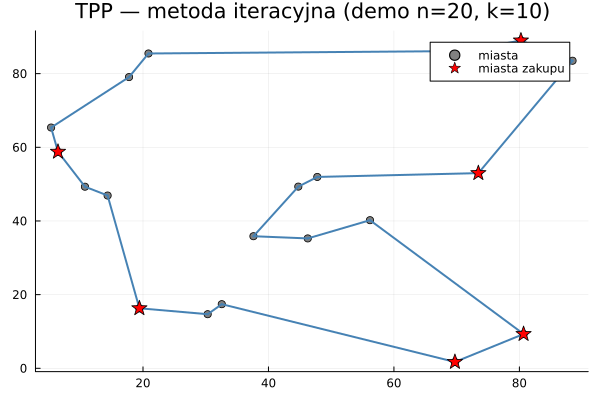

In [6]:
# Funkcja rysująca trasę i miasta zakupu
function plot_tpp_tour(X, Y, x_val, y_val=nothing; title_str="")
    n = size(x_val, 1)
    plt = Plots.scatter(X, Y; label="miasta", legend=:topright,
                        title=title_str, ms=4, color=:gray)
    for (i, j) in selected_edges(x_val, n)
        if i < j
            Plots.plot!(plt, [X[i], X[j]], [Y[i], Y[j]];
                        color=:steelblue, lw=2, label="")
        end
    end
    if y_val !== nothing
        purchase_cities = unique([findfirst(>(0.5), y_val[p, :])
                                  for p in 1:size(y_val, 1)])
        Plots.scatter!(plt, X[purchase_cities], Y[purchase_cities];
                       color=:red, ms=8, marker=:star5, label="miasta zakupu")
    end
    return plt
end

plot_tpp_tour(X_demo, Y_demo,
              JuMP.value.(model_demo[:x]),
              JuMP.value.(model_demo[:y]);
              title_str="TPP — metoda iteracyjna (demo n=$(n_demo), k=$(k_demo))")

## Algorytm genetyczny dla TPP

Reprezentacja chromosomu pozostaje taka jak w `tsp-genetic.ipynb`: tablica `tour::Vector{Int}` długości `n`, gdzie `tour[i]` to miasto następujące po mieście `i` w cyklu Hamiltona. Krzyżowanie i mutacja są zdefiniowane na permutacjach.

W TPP funkcja kosztu wymaga jednak również decyzji o miejscach zakupów. Ponieważ przy wymogu odwiedzenia wszystkich miast wybór ten jest **rozdzielny** względem trasy, dla danej trasy obliczamy go zachłannie — dla każdego przedmiotu wybieramy najtańsze miasto. Składa się to do funkcji kosztu, którą minimalizuje GA.

In [7]:
# Konwersja permutacja <-> sekwencja inwersji (jak w tsp-genetic)
function perm_to_inv(perm::Vector)
    N = length(perm)
    inv_seq = zeros(Int, N)
    for i in 1:N
        m = 1
        while perm[m] != i
            if perm[m] > i
                inv_seq[i] += 1
            end
            m += 1
        end
    end
    return inv_seq
end

function inv_to_perm(inv_seq::Vector)
    N = length(inv_seq)
    pos = zeros(Int, N)
    for i in N:-1:1
        for m in (i+1):N
            if pos[m] >= inv_seq[i] + 1
                pos[m] += 1
            end
        end
        pos[i] = inv_seq[i] + 1
    end
    perm = zeros(Int, N)
    for i in 1:N
        perm[pos[i]] = i
    end
    return perm
end

# czy permutacja "next-city" zawiera podcykl (zaczynamy od 1)
function has_subtour(perm::Vector)
    c = 1
    for _ in 1:(length(perm) - 1)
        c = perm[c]
        if c == 1
            return true
        end
    end
    return false
end

# mutacja przez wymianę dwóch pozycji (z sanity-check braku podcyklu)
function mutate_swap(recombinant::AbstractVector;
        rng::AbstractRNG=Random.default_rng())
    N = length(recombinant)
    first_iter = true
    while first_iter || has_subtour(recombinant)
        i = rand(rng, 1:N); j = rand(rng, 1:N)
        recombinant[i], recombinant[j] = recombinant[j], recombinant[i]
        first_iter = false
    end
    return recombinant
end

# Krzyżowanie oparte o inwersję permutacji (jak w tsp-genetic.ipynb)
function recombine_inv(v1::T, v2::T;
        rng::AbstractRNG=Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    i1 = perm_to_inv(v1); i2 = perm_to_inv(v2)
    cp = rand(rng, 2:(N - 1))
    c1 = vcat(i1[1:cp], i2[(cp+1):N])
    c2 = vcat(i2[1:cp], i1[(cp+1):N])
    return inv_to_perm(c1), inv_to_perm(c2)
end

recombine_inv (generic function with 1 method)

In [ ]:
# Bazowa funkcja kosztu TPP (bez wag) dla GA.
# Trasa to permutacja "next-city". Jeśli jest podcyklem, dodajemy karę.
# Dla każdej trasy zakupy są niezależne: dla każdego przedmiotu min cena po miastach.
function tpp_cost(tour::Vector{Int}, d, cost_item_city)
    n = size(d, 1); K = size(cost_item_city, 1)
    tour_dist = 0.0
    @inbounds for i in 1:n
        tour_dist += d[i, tour[i]]
    end
    penalty = has_subtour(tour) ? 1e6 : 0.0
    purchases = 0.0
    @inbounds for p in 1:K
        purchases += minimum(view(cost_item_city, p, :))
    end
    return tour_dist + purchases + penalty
end

# Uruchomienie GA z budżetem czasu.
# epsilon=1e-4 — bardzo ciasny próg zbieżności, dzięki czemu GA eksploruje
# do wyczerpania `time_limit` lub `iterations`, zamiast zatrzymywać się
# przy pierwszej chwilowej stagnacji (jak dla luźniejszego epsilon=0.05).
function run_ga_tpp(d, cost_item_city;
        crossover_op=recombine_inv,
        pop_size=200, max_iters=2000, time_limit=55.0,
        cost_fn=nothing, seed=1)
    n = size(d, 1)
    Random.seed!(seed)
    x0 = [mod1(i + 1, n) for i in 1:n]
    cf = cost_fn === nothing ? (t -> tpp_cost(t, d, cost_item_city)) : cost_fn
    sol = Evolutionary.optimize(
        cf, x0,
        GA(; populationSize=pop_size,
              selection=tournament(3),
              crossover=crossover_op,
              mutation=mutate_swap,
              epsilon=1e-4,
              crossoverRate=0.9),
        Evolutionary.Options(; iterations=max_iters,
                               time_limit=time_limit,
                               show_trace=false)
    )
    return sol
end

# Parametry GA dobrane do rozmiaru instancji (limit 60s na każdy przebieg)
ga_params(n, K) =
    n <= 50  ? (pop_size=15000, max_iters=1000000, time_limit=55.0) :
                (pop_size=10000, max_iters=1000000, time_limit=55.0)

# Budżet czasowy dla MIP — treść zadania ogranicza tylko GA, ale dla (n=100, k=100)
# GLPK potrafi liczyć wiele minut. Ucinamy łączny czas iteracji eliminacji
# podcykli; jeśli MIP nie zdąży, zwrócimy status :timeout.
mip_budget(n, K) = n <= 50 ? 120.0 : 180.0

mip_budget (generic function with 1 method)

In [40]:
# Uruchomienie GA na instancji demonstracyjnej
sol_demo = run_ga_tpp(d_demo, ci_demo;
    pop_size=300, max_iters=500, time_limit=15.0)
@printf("GA (demo): koszt = %.2f, czas = %.2f s, iteracji = %d\n",
    sol_demo.minimum, sol_demo.time_run, sol_demo.iterations)
@printf("MIP (demo): koszt = %.2f, czas = %.3f s\n",
    objective_value(model_demo), t_demo)

GA (demo): koszt = 1012.58, czas = 0.06 s, iteracji = 92
MIP (demo): koszt = 909.65, czas = 0.020 s


## Porównanie wydajności na 9 losowych instancjach

Zgodnie z treścią zadania uruchamiamy oba podejścia na po trzech instancjach trzech rozmiarów. Parametry GA (rozmiar populacji, liczba iteracji, limit czasu) są dobrane przez `ga_params` tak, aby żaden przebieg nie przekroczył 60 sekund.

**Uwaga praktyczna:** treść zadania ogranicza tylko czas GA. Iteracyjna metoda MIP w GLPK potrafi jednak liczyć dla `(n=100, k=100)` od kilku do kilkunastu minut na instancję — dlatego dodajemy łączny budżet czasowy `mip_budget` (120 s dla `n=50`, 180 s dla `n=100`). Jeśli MIP nie zdąży udowodnić optymalności i wyeliminować wszystkich podcykli, w tabeli pokazujemy `TIMEOUT`. Dla mniejszych instancji status `optimal` oznacza udowodnione optimum.

In [46]:
# Konfiguracja: trzy seedy dla każdej z trzech kombinacji (n, k)
configs = [
    (50, 20, 11), (50, 20, 12), (50, 20, 13),
    (50, 50, 21), (50, 50, 22), (50, 50, 23),
    (100, 100, 21), (100, 100, 42), (100, 100, 33),
]

println("|  n |   k | seed |  MIP koszt | MIP czas[s] | MIP status |   GA koszt | GA czas[s] |")
println("|---:|----:|-----:|-----------:|------------:|:-----------|-----------:|-----------:|")
results_3 = []
for (n_i, K_i, seed) in configs
    _, _, d_i, ci_i = generate_random_tpp(n_i, K_i; random_seed=seed)
    
    t0 = time()
    mip_model, _, _, st_mip = solve_tpp_iterative(d_i, ci_i;
        verbose=false, total_budget=mip_budget(n_i, K_i))
    t_mip = time() - t0


    cost_mip_str = if st_mip == :timeout
        "  TIMEOUT"
    else
        @sprintf("%10.2f", objective_value(mip_model))
    end
    # GA
    p = ga_params(n_i, K_i)
    t_ga0 = time()
    sol_ga = run_ga_tpp(d_i, ci_i;
        pop_size=p.pop_size, max_iters=p.max_iters,
        time_limit=p.time_limit, seed=seed)
    t_ga = time() - t_ga0
    cost_ga = sol_ga.minimum
    push!(results_3, (n_i, K_i, seed, st_mip, t_mip, cost_ga, t_ga))
    @printf("| %2d | %3d | %4d | %s | %11.3f | %-10s | %10.2f | %10.2f |\n",
        n_i, K_i, seed, cost_mip_str, t_mip, String(st_mip), cost_ga, t_ga)
end

|  n |   k | seed |  MIP koszt | MIP czas[s] | MIP status |   GA koszt | GA czas[s] |
|---:|----:|-----:|-----------:|------------:|:-----------|-----------:|-----------:|
| 50 |  20 |   11 |    1652.60 |       1.117 | optimal    |    2075.33 |      14.48 |
| 50 |  20 |   12 |    1613.49 |       0.066 | optimal    |    2021.76 |      15.55 |
| 50 |  20 |   13 |    1609.51 |       0.069 | optimal    |    2149.23 |       9.08 |
| 50 |  50 |   21 |    3191.16 |       1.097 | optimal    |    4487.69 |       2.55 |
| 50 |  50 |   22 |    3156.68 |       0.813 | optimal    |    3519.12 |      17.13 |
| 50 |  50 |   23 |    3149.34 |       3.429 | optimal    |    3627.00 |      13.26 |
| 100 | 100 |   21 |    5873.96 |     159.112 | optimal    |    7221.16 |      55.21 |
| 100 | 100 |   42 |    5865.00 |     155.976 | optimal    |    7274.33 |      55.20 |
| 100 | 100 |   33 |    5869.21 |      54.951 | optimal    |    9299.14 |       6.06 |


## Zadanie na 4.0 — wagi przedmiotów

Każdy przedmiot $p$ ma wagę $w_p$. Do funkcji kosztu (tylko w GA — w JuMP zostawiamy bazową) dodajemy składnik

$$
\alpha \sum_{p=1}^{k} w_p \cdot d^{\text{end}}\!\bigl(\text{miasto zakupu } p\bigr),
$$

gdzie $d^{\text{end}}(c)$ to długość trasy od miasta $c$ do końca cyklu (powrót do depo, czyli miasta startowego $1$).

**Dobór $\alpha$.** Wagi losujemy z rozkładu $\mathcal{U}(0.5, 1.5)$, więc waga średnia $\bar{w}=1$. Średnia cena to $\bar{c}\approx 100$. Maksymalna odległość w linii prostej to $D_{\max}=\max_{i,j} d_{ij}$. Wymagamy, by transport przedmiotu o średniej wadze pomiędzy najdalszymi miastami stanowił 1% średniej ceny:

$$
\alpha \cdot \bar{w}\cdot D_{\max} = 0.01\cdot \bar{c}\quad\Longrightarrow\quad
\alpha = \dfrac{0.01\cdot \bar{c}}{\bar{w}\cdot D_{\max}}.
$$

In [11]:
# Generator wag i wyznaczenie współczynnika alpha
function generate_weights(K; seed=1)
    rng = Random.MersenneTwister(seed + 7777)
    return 0.5 .+ rand(rng, K)   # rozkład U(0.5, 1.5)
end

function compute_alpha(d, cost_item_city, weights)
    max_dist = maximum(d)
    mean_weight = mean(weights)
    mean_price = mean(cost_item_city)
    return 0.01 * mean_price / (mean_weight * max_dist)
end

# Helper: odtworzenie kolejności miast w cyklu z reprezentacji "next-city".
function tour_order_from_next(tour::Vector{Int}; start::Int=1)
    n = length(tour)
    order = zeros(Int, n)
    order[1] = start
    @inbounds for i in 2:n
        order[i] = tour[order[i-1]]
    end
    return order
end

# Funkcja kosztu uwzględniająca wagi: dla każdego przedmiotu wybieramy
# miasto, które minimalizuje cena + alpha * waga * dist_to_end(miasto).
function tpp_cost_weighted(tour::Vector{Int}, d, cost_item_city, weights, alpha)
    n = size(d, 1); K = size(cost_item_city, 1)
    tour_dist = 0.0
    @inbounds for i in 1:n
        tour_dist += d[i, tour[i]]
    end
    if has_subtour(tour)
        return tour_dist + 1e6
    end
    order = tour_order_from_next(tour; start=1)
    # dist_to_end[idx] — długość trasy od pozycji idx do powrotu do depo
    dist_to_end = zeros(n)
    dist_to_end[n] = d[order[n], order[1]]
    @inbounds for idx in (n-1):-1:1
        dist_to_end[idx] = dist_to_end[idx + 1] + d[order[idx], order[idx + 1]]
    end
    pos = zeros(Int, n)
    @inbounds for idx in 1:n
        pos[order[idx]] = idx
    end
    purchases = 0.0
    @inbounds for p in 1:K
        best = Inf
        for c in 1:n
            cc = cost_item_city[p, c] + alpha * weights[p] * dist_to_end[pos[c]]
            best = min(best, cc)
        end
        purchases += best
    end
    return tour_dist + purchases
end

tpp_cost_weighted (generic function with 1 method)

In [23]:
# Pomocniczo: koszt plain dla konkretnej trasy "next-city"
function tpp_plain_cost_for_tour(tour::Vector{Int}, d, cost_item_city)
    n = length(tour)
    tour_dist = 0.0
    @inbounds for i in 1:n
        tour_dist += d[i, tour[i]]
    end
    purchases = 0.0
    @inbounds for p in 1:size(cost_item_city, 1)
        purchases += minimum(view(cost_item_city, p, :))
    end
    return tour_dist + purchases
end

# Odtworzenie trasy "next-city" z rozwiązania JuMP x[i,j]
function next_tour_from_x(x_val; start=1)
    n = size(x_val, 1)
    neigh = [Int[] for _ in 1:n]
    for i in 1:n, j in (i+1):n
        if x_val[i, j] > 0.5
            push!(neigh[i], j)
            push!(neigh[j], i)
        end
    end

    tour = zeros(Int, n)
    prev = 0
    cur = start
    for _ in 1:(n - 1)
        nxts = neigh[cur]
        nxt = (nxts[1] != prev) ? nxts[1] : nxts[2]
        tour[cur] = nxt
        prev, cur = cur, nxt
    end
    tour[cur] = start
    return tour
end

configs_4 = [(50, 20, 41), (50, 50, 42), (100, 100, 43)]

println("\nPorównanie 4.0 w obu metrykach")
println("|  n |   k | seed | algorytm | plain koszt | weighted koszt | czas [s] | status |")
println("|---:|----:|-----:|:---------|------------:|---------------:|---------:|:-------|")

for (n_i, K_i, seed) in configs_4
    _, _, d_i, ci_i = generate_random_tpp(n_i, K_i; random_seed=seed)
    weights_i = generate_weights(K_i; seed=seed)
    alpha_i = compute_alpha(d_i, ci_i, weights_i)
    p = ga_params(n_i, K_i)

    # MIP
    t0 = time()
    mip_model, _, _, st_mip = solve_tpp_iterative(d_i, ci_i;
        verbose=false, total_budget=mip_budget(n_i, K_i))
    t_mip_wall = time() - t0

    if st_mip != :timeout
        x_mip = JuMP.value.(mip_model[:x])
        tour_mip = next_tour_from_x(x_mip)
        plain_mip = tpp_plain_cost_for_tour(tour_mip, d_i, ci_i)
        weighted_mip = tpp_cost_weighted(tour_mip, d_i, ci_i, weights_i, alpha_i)

        @printf("| %2d | %3d | %4d | %-8s | %11.2f | %14.2f | %8.2f | %-7s |\n",
            n_i, K_i, seed, "MIP", plain_mip, weighted_mip, t_mip_wall, String(st_mip))
    else
        @printf("| %2d | %3d | %4d | %-8s | %11s | %14s | %8.2f | %-7s |\n",
            n_i, K_i, seed, "MIP", "TIMEOUT", "TIMEOUT", t_mip_wall, String(st_mip))
    end

    # GA bez wag
    t0 = time()
    sol_nw = run_ga_tpp(d_i, ci_i;
        pop_size=p.pop_size, max_iters=p.max_iters,
        time_limit=p.time_limit, seed=seed)
    t_nw = time() - t0
    tour_nw = Evolutionary.minimizer(sol_nw)
    plain_nw = tpp_plain_cost_for_tour(tour_nw, d_i, ci_i)
    weighted_nw = tpp_cost_weighted(tour_nw, d_i, ci_i, weights_i, alpha_i)

    @printf("| %2d | %3d | %4d | %-8s | %11.2f | %14.2f | %8.2f | %-7s |\n",
        n_i, K_i, seed, "GA plain", plain_nw, weighted_nw, t_nw, "ok")

    # GA z wagami
    cost_fn_w = t -> tpp_cost_weighted(t, d_i, ci_i, weights_i, alpha_i)
    t0 = time()
    sol_w = run_ga_tpp(d_i, ci_i;
        pop_size=p.pop_size, max_iters=p.max_iters,
        time_limit=p.time_limit, cost_fn=cost_fn_w, seed=seed)
    t_w = time() - t0
    tour_w = Evolutionary.minimizer(sol_w)
    plain_w = tpp_plain_cost_for_tour(tour_w, d_i, ci_i)
    weighted_w = tpp_cost_weighted(tour_w, d_i, ci_i, weights_i, alpha_i)

    @printf("| %2d | %3d | %4d | %-8s | %11.2f | %14.2f | %8.2f | %-7s |\n",
        n_i, K_i, seed, "GA w", plain_w, weighted_w, t_w, "ok")
end



Porównanie 4.0 w obu metrykach
|  n |   k | seed | algorytm | plain koszt | weighted koszt | czas [s] | status |
|---:|----:|-----:|:---------|------------:|---------------:|---------:|:-------|
| 50 |  20 |   41 | MIP      |     1578.93 |        1618.75 |     0.06 | optimal |
| 50 |  20 |   41 | GA plain |     2498.05 |        2592.38 |     0.28 | ok      |
| 50 |  20 |   41 | GA w     |     2241.90 |        2302.12 |     1.04 | ok      |
| 50 |  50 |   42 | MIP      |     3114.80 |        3222.39 |     0.34 | optimal |
| 50 |  50 |   42 | GA plain |     4662.30 |        4903.87 |     7.57 | ok      |
| 50 |  50 |   42 | GA w     |     3741.01 |        3870.06 |     1.07 | ok      |
| 100 | 100 |   43 | MIP      |     5891.28 |        6070.71 |     3.91 | optimal |
| 100 | 100 |   43 | GA plain |     8111.23 |        8593.15 |     2.85 | ok      |
| 100 | 100 |   43 | GA w     |     8391.10 |        8872.83 |     1.99 | ok      |


## Zadanie na 4.0 — krzyżowanie PMX

Implementacja klasycznego *Partially Mapped Crossover*: losujemy dwa punkty cięcia $a \le b$, kopiujemy segment $[a,b]$ z jednego rodzica do dziecka, a pozycje poza segmentem uzupełniamy z drugiego rodzica, rozwiązując konflikty przez mapowanie zdefiniowane przez segmenty.

In [13]:
# PMX — Partially Mapped Crossover
function recombine_pmx(v1::T, v2::T;
        rng::AbstractRNG=Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    a = rand(rng, 1:N); b = rand(rng, 1:N)
    if a > b; a, b = b, a; end

    c1 = copy(v2); c2 = copy(v1)
    c1[a:b] .= v1[a:b]
    c2[a:b] .= v2[a:b]

    used1 = Set(c1[a:b]); used2 = Set(c2[a:b])
    map1 = Dict(v1[i] => v2[i] for i in a:b)   # pomocnicze do c1
    map2 = Dict(v2[i] => v1[i] for i in a:b)   # pomocnicze do c2

    @inbounds for i in 1:N
        if a <= i <= b; continue; end
        # wypełniamy c1 z v2[i], rozwiązując konflikty przez mapowanie
        v = v2[i]
        while v in used1
            v = map1[v]
        end
        c1[i] = v
        v = v1[i]
        while v in used2
            v = map2[v]
        end
        c2[i] = v
    end
    return c1, c2
end

# Test poprawności: po krzyżowaniu wynik nadal jest permutacją 1:N
let
    p1 = randperm(20); p2 = randperm(20)
    c1, c2 = recombine_pmx(p1, p2)
    @assert sort(c1) == 1:20
    @assert sort(c2) == 1:20
    println("PMX działa poprawnie: dzieci są permutacjami 1:20")
end

PMX działa poprawnie: dzieci są permutacjami 1:20


In [21]:
# Porównanie krzyżowania PMX vs inwersja
println("\nPorównanie krzyżowań (PMX vs inwersja):")
println("|  n |   k | seed | inwersja koszt | inv czas[s] |  PMX koszt | PMX czas[s] |")
println("|---:|----:|-----:|---------------:|------------:|-----------:|------------:|")
for (n_i, K_i, seed) in [(50, 20, 51), (50, 50, 52), (100, 100, 53)]
    _, _, d_i, ci_i = generate_random_tpp(n_i, K_i; random_seed=seed)
    p = ga_params(n_i, K_i)

    t0 = time()
    sol_inv = run_ga_tpp(d_i, ci_i;
        crossover_op=recombine_inv,
        pop_size=p.pop_size, max_iters=p.max_iters,
        time_limit=p.time_limit, seed=seed)
    t_inv = time() - t0

    t0 = time()
    sol_pmx = run_ga_tpp(d_i, ci_i;
        crossover_op=recombine_pmx,
        pop_size=p.pop_size, max_iters=p.max_iters,
        time_limit=p.time_limit, seed=seed)
    t_pmx = time() - t0

    @printf("| %2d | %3d | %4d | %14.2f | %11.2f | %10.2f | %11.2f |\n",
        n_i, K_i, seed, sol_inv.minimum, t_inv, sol_pmx.minimum, t_pmx)
end


Porównanie krzyżowań (PMX vs inwersja):
|  n |   k | seed | inwersja koszt | inv czas[s] |  PMX koszt | PMX czas[s] |
|---:|----:|-----:|---------------:|------------:|-----------:|------------:|
| 50 |  20 |   51 |        2138.29 |        0.51 |    2903.08 |        3.05 |
| 50 |  50 |   52 |        4808.96 |        6.07 |    4458.73 |        3.89 |
| 100 | 100 |   53 |        9851.72 |       10.98 |    9511.05 |        7.84 |


## Zadanie na 5.0 — TPP z opcjonalnymi miastami

Konsument nie musi odwiedzać miast, w których niczego nie kupuje. Wprowadzamy zmienną binarną $v_i\in\{0,1\}$ — czy miasto $i$ zostało odwiedzone. Ograniczenia stopnia stają się:

$$
\sum_j x_{ij} = 2\,v_i, \quad y_{p,c} \le v_c, \quad v_1 = 1.
$$

Eliminacja podcykli jest uogólniona: dla zbioru $S$ odwiedzonych miast nie zawierającego depo

$$
\sum_{i,j\in S, i<j} x_{ij} \le \sum_{i\in S} v_i - 1.
$$

Generujemy dane tak, by w optimum konsument odwiedzał przynajmniej 3 miasta i pomijał przynajmniej 2. W praktyce ustawiamy kilka ostatnich miast jako odległe i drogie, więc rozwiązanie ma wyraźną motywację do ich pomijania.


In [30]:
# Generator instancji z miastami-przynętami (do pominięcia)
function generate_random_tpp_skippable(n, K; n_skip=2, random_seed=1)
    rng = Random.MersenneTwister(random_seed)
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    # Ostatnie n_skip miast — daleko od reszty
    for i in (n - n_skip + 1):n
        X[i] = 500.0 + 100.0 * rand(rng)
        Y[i] = 500.0 + 100.0 * rand(rng)
    end
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]
    cost_item_city = 50 .+ 100 .* rand(rng, K, n)
    # Wysokie ceny w miastach do pominięcia
    cost_item_city[:, (n - n_skip + 1):n] .+= 200.0
    return X, Y, d, cost_item_city
end

generate_random_tpp_skippable (generic function with 1 method)

In [31]:
# Model JuMP dla wariantu z opcjonalnym odwiedzaniem miast
function build_tpp_model_optional(d, cost_item_city)
    n = size(d, 1)
    K = size(cost_item_city, 1)
    model = Model(GLPK.Optimizer)
    @variable(model, x[1:n, 1:n], Bin, Symmetric)
    @variable(model, v[1:n], Bin)
    @variable(model, y[1:K, 1:n], Bin)
    @objective(model, Min,
        sum(d .* x) / 2 +
        sum(cost_item_city[p, c] * y[p, c] for p in 1:K, c in 1:n)
    )
    @constraint(model, v[1] == 1)                                   # depo zawsze odwiedzane
    @constraint(model, [i in 1:n], sum(x[i, :]) == 2 * v[i])
    @constraint(model, [i in 1:n], x[i, i] == 0)
    @constraint(model, [p in 1:K], sum(y[p, :]) == 1)
    @constraint(model, [p in 1:K, c in 1:n], y[p, c] <= v[c])
    return model
end

# Wyszukanie spójnej składowej krawędziowej nie zawierającej depa (miasto 1)
function find_subtour_component(x_val, v_val, n)
    edges = Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if i < j && x_val[i, j] > 0.5]
    visited = [i for i in 1:n if v_val[i] > 0.5]
    if isempty(visited); return Int[]; end
    adj = Dict(i => Int[] for i in visited)
    for (i, j) in edges
        push!(adj[i], j); push!(adj[j], i)
    end
    seen = Set{Int}()
    components = Vector{Int}[]
    for s in visited
        if s in seen; continue; end
        comp = Int[]; q = [s]
        while !isempty(q)
            u = popfirst!(q)
            if u in seen; continue; end
            push!(seen, u); push!(comp, u)
            for w in adj[u]
                if !(w in seen); push!(q, w); end
            end
        end
        push!(components, comp)
    end
    # zwracamy składową bez depa (jeśli istnieje i ma >= 2 miasta)
    for comp in components
        if !(1 in comp) && length(comp) >= 2
            return comp
        end
    end
    return Int[]
end

# "Lazy constraints" w wersji iteracyjnej (jak w przykładzie z TSP)
function solve_tpp_optional(d, cost_item_city; verbose=false)
    n = size(d, 1)
    model = build_tpp_model_optional(d, cost_item_city)
    set_silent(model)
    optimize!(model)
    @assert is_solved_and_feasible(model)
    total_time = solve_time(model)
    iters = 0
    while true
        x_val = JuMP.value.(model[:x]); v_val = JuMP.value.(model[:v])
        sub = find_subtour_component(x_val, v_val, n)
        if isempty(sub); break; end
        iters += 1
        verbose && println("Iter $(iters): podcykl rozmiaru $(length(sub))")
        @constraint(model,
            sum(model[:x][i, j] for i in sub, j in sub if i < j) <=
            sum(model[:v][i] for i in sub) - 1)
        optimize!(model)
        @assert is_solved_and_feasible(model)
        total_time += solve_time(model)
    end
    return model, total_time, iters
end

solve_tpp_optional (generic function with 1 method)

In [36]:
# =========================
# GA dla TPP z opcjonalnymi miastami
# Chromosom:
# - pierwsze n-1 genów: permutacja miast 2:n
# - kolejne K genów: buy_city[p] ∈ 1:n
# Odwiedzane miasta to dokładnie: {1} ∪ {buy_city[p]}
# =========================

function split_optional_chromosome(chrom::Vector{Int}, n, K)
    order = chrom[1:(n-1)]
    buy_city = chrom[n:(n-1+K)]
    return order, buy_city
end

function build_optional_route(order::Vector{Int}, buy_city::Vector{Int})
    visited = Set(buy_city)
    push!(visited, 1)  # depo zawsze odwiedzane
    route = Int[1]
    for c in order
        if c in visited
            push!(route, c)
        end
    end
    return route
end

function route_length(route::Vector{Int}, d)
    m = length(route)
    if m == 1
        return 0.0
    end
    total = 0.0
    @inbounds for i in 1:(m-1)
        total += d[route[i], route[i+1]]
    end
    total += d[route[end], route[1]]  # powrót do depo
    return total
end

function tpp_optional_cost_ga(chrom::Vector{Int}, d, cost_item_city)
    n = size(d, 1)
    K = size(cost_item_city, 1)
    order, buy_city = split_optional_chromosome(chrom, n, K)

    # pierwsza część musi być permutacją miast 2:n
    if sort(order) != collect(2:n)
        return 1e9
    end

    # miasta zakupu muszą należeć do 1:n
    if any(c -> c < 1 || c > n, buy_city)
        return 1e9
    end

    route = build_optional_route(order, buy_city)

    # zgodność z modelem MIP: cykl musi obejmować co najmniej 3 odwiedzone miasta
    if length(route) < 3
        return 1e9
    end

    travel_cost = route_length(route, d)
    purchase_cost = sum(cost_item_city[p, buy_city[p]] for p in 1:K)

    return travel_cost + purchase_cost
end


function tpp_optional_cost_ga_weighted(chrom::Vector{Int}, d, cost_item_city, weights, alpha)
    n = size(d, 1)
    K = size(cost_item_city, 1)
    order, buy_city = split_optional_chromosome(chrom, n, K)

    if sort(order) != collect(2:n)
        return 1e9
    end
    if any(c -> c < 1 || c > n, buy_city)
        return 1e9
    end

    route = build_optional_route(order, buy_city)

    # zgodność z modelem MIP: co najmniej 3 odwiedzone miasta
    if length(route) < 3
        return 1e9
    end

    travel_cost = route_length(route, d)

    pos = Dict(route[i] => i for i in eachindex(route))
    m = length(route)
    dist_to_end = zeros(Float64, m)

    dist_to_end[m] = d[route[m], route[1]]
    @inbounds for i in (m-1):-1:1
        dist_to_end[i] = dist_to_end[i+1] + d[route[i], route[i+1]]
    end

    purchase_cost = 0.0
    @inbounds for p in 1:K
        c = buy_city[p]
        purchase_cost += cost_item_city[p, c] + alpha * weights[p] * dist_to_end[pos[c]]
    end

    return travel_cost + purchase_cost
end


function initial_optional_chromosome(n, K)
    order = collect(2:n)
    buy_city = ones(Int, K)
    return vcat(order, buy_city)
end

function mutate_optional!(chrom::Vector{Int}, n, K;
        rng::AbstractRNG=Random.default_rng())
    if rand(rng) < 0.5
        # mutacja części permutacyjnej
        i = rand(rng, 1:(n-1))
        j = rand(rng, 1:(n-1))
        chrom[i], chrom[j] = chrom[j], chrom[i]
    else
        # mutacja części zakupowej
        p = rand(rng, 1:K)
        chrom[n - 1 + p] = rand(rng, 1:n)
    end
    return chrom
end

function make_optional_crossover(n, K; perm_crossover=recombine_pmx)
    function crossover(v1::Vector{Int}, v2::Vector{Int};
            rng::AbstractRNG=Random.default_rng())
        ord1 = v1[1:(n-1)]
        ord2 = v2[1:(n-1)]
        buy1 = v1[n:(n-1+K)]
        buy2 = v2[n:(n-1+K)]

        child_ord1, child_ord2 = perm_crossover(ord1, ord2; rng=rng)

        child_buy1 = similar(buy1)
        child_buy2 = similar(buy2)
        @inbounds for p in 1:K
            if rand(rng) < 0.5
                child_buy1[p] = buy1[p]
                child_buy2[p] = buy2[p]
            else
                child_buy1[p] = buy2[p]
                child_buy2[p] = buy1[p]
            end
        end

        return vcat(child_ord1, child_buy1), vcat(child_ord2, child_buy2)
    end
    return crossover
end

function make_optional_mutation(n, K)
    return (chrom; rng=Random.default_rng()) -> mutate_optional!(chrom, n, K; rng=rng)
end

function run_ga_tpp_optional(d, cost_item_city;
        pop_size=400, max_iters=4000, time_limit=55.0, seed=1,
        cost_fn=nothing, perm_crossover=recombine_pmx)

    n = size(d, 1)
    K = size(cost_item_city, 1)
    Random.seed!(seed)

    x0 = initial_optional_chromosome(n, K)
    cf = cost_fn === nothing ? (x -> tpp_optional_cost_ga(x, d, cost_item_city)) : cost_fn
    crossover_op = make_optional_crossover(n, K; perm_crossover=perm_crossover)
    mutation_op = make_optional_mutation(n, K)

    sol = Evolutionary.optimize(
        cf, x0,
        GA(; populationSize=pop_size,
              selection=tournament(3),
              crossover=crossover_op,
              mutation=mutation_op,
              epsilon=1e-4,
              crossoverRate=0.9),
        Evolutionary.Options(; iterations=max_iters,
                               time_limit=time_limit,
                               show_trace=false)
    )
    return sol
end

function describe_optional_ga_solution(sol, d, cost_item_city)
    n = size(d, 1)
    K = size(cost_item_city, 1)
    chrom = Evolutionary.minimizer(sol)
    order, buy_city = split_optional_chromosome(chrom, n, K)
    route = build_optional_route(order, buy_city)

    visited = sort(unique(route))
    skipped = setdiff(collect(1:n), visited)

    println("Trasa GA optional:")
    println(route)
    println("Miasta odwiedzone ($(length(visited))): ", visited)
    println("Miasta pominięte ($(length(skipped))): ", skipped)

    println("\nZakupy:")
    @inbounds for p in 1:K
        @printf("  Przedmiot %d -> miasto %d (cena %.2f)\n",
            p, buy_city[p], cost_item_city[p, buy_city[p]])
    end
end

function plot_tpp_optional_ga(X, Y, sol, cost_item_city; title_str="")
    n = length(X)
    K = size(cost_item_city, 1)
    chrom = Evolutionary.minimizer(sol)
    order, buy_city = split_optional_chromosome(chrom, n, K)
    route = build_optional_route(order, buy_city)

    visited = sort(unique(route))
    skipped = setdiff(collect(1:n), visited)
    purchase_cities = sort(unique(buy_city))

    plt = Plots.scatter(X[skipped], Y[skipped];
        label="pominięte", color=:lightgray, marker=:xcross, ms=4,
        legend=:topright, title=title_str)

    Plots.scatter!(plt, X[visited], Y[visited];
        label="odwiedzone", color=:gray, ms=5)

    for i in 1:(length(route)-1)
        a, b = route[i], route[i+1]
        Plots.plot!(plt, [X[a], X[b]], [Y[a], Y[b]];
            color=:steelblue, lw=2, label="")
    end
    if length(route) >= 2
        a, b = route[end], route[1]
        Plots.plot!(plt, [X[a], X[b]], [Y[a], Y[b]];
            color=:steelblue, lw=2, label="")
    end

    Plots.scatter!(plt, X[purchase_cities], Y[purchase_cities];
        color=:red, ms=8, marker=:star5, label="zakupy")

    return plt
end


plot_tpp_optional_ga (generic function with 1 method)

In [37]:
# Generujemy instancję, w której optimum pomija przynajmniej 2 miasta i odwiedza >=3
n_opt, k_opt = 12, 6
X_opt, Y_opt, d_opt, ci_opt = generate_random_tpp_skippable(n_opt, k_opt;
    n_skip=3, random_seed=99)

println("=== MIP optional ===")
model_opt, t_opt, it_opt = solve_tpp_optional(d_opt, ci_opt; verbose=true)
v_val = JuMP.value.(model_opt[:v])
y_val = JuMP.value.(model_opt[:y])

visited = [i for i in 1:n_opt if v_val[i] > 0.5]
skipped = [i for i in 1:n_opt if v_val[i] <= 0.5]
@printf("\nKoszt rozwiązania MIP: %.2f\n", objective_value(model_opt))
@printf("Czas: %.3f s, iteracji: %d\n", t_opt, it_opt)
println("Miasta odwiedzone ($(length(visited))): ", visited)
println("Miasta pominięte ($(length(skipped))): ", skipped)
@assert length(visited) >= 3
@assert length(skipped) >= 2

println("\nZakupy MIP:")
for p in 1:k_opt
    c = findfirst(>(0.5), y_val[p, :])
    @printf("  Przedmiot %d -> miasto %d (cena %.2f)\n", p, c, ci_opt[p, c])
end

println("\n=== GA optional ===")
sol_ga_optional = run_ga_tpp_optional(d_opt, ci_opt;
    pop_size=400, max_iters=4000, time_limit=20.0, seed=99)

@printf("Koszt rozwiązania GA optional: %.2f\n", sol_ga_optional.minimum)
describe_optional_ga_solution(sol_ga_optional, d_opt, ci_opt)


=== MIP optional ===

Koszt rozwiązania MIP: 459.01
Czas: 0.001 s, iteracji: 0
Miasta odwiedzone (3): [1, 8, 9]
Miasta pominięte (9): [2, 3, 4, 5, 6, 7, 10, 11, 12]

Zakupy MIP:
  Przedmiot 1 -> miasto 1 (cena 77.00)
  Przedmiot 2 -> miasto 8 (cena 56.70)
  Przedmiot 3 -> miasto 8 (cena 55.67)
  Przedmiot 4 -> miasto 9 (cena 58.20)
  Przedmiot 5 -> miasto 1 (cena 51.73)
  Przedmiot 6 -> miasto 8 (cena 64.52)

=== GA optional ===
Koszt rozwiązania GA optional: 459.01
Trasa GA optional:
[1, 8, 9]
Miasta odwiedzone (3): [1, 8, 9]
Miasta pominięte (9): [2, 3, 4, 5, 6, 7, 10, 11, 12]

Zakupy:
  Przedmiot 1 -> miasto 1 (cena 77.00)
  Przedmiot 2 -> miasto 8 (cena 56.70)
  Przedmiot 3 -> miasto 8 (cena 55.67)
  Przedmiot 4 -> miasto 9 (cena 58.20)
  Przedmiot 5 -> miasto 1 (cena 51.73)
  Przedmiot 6 -> miasto 8 (cena 64.52)


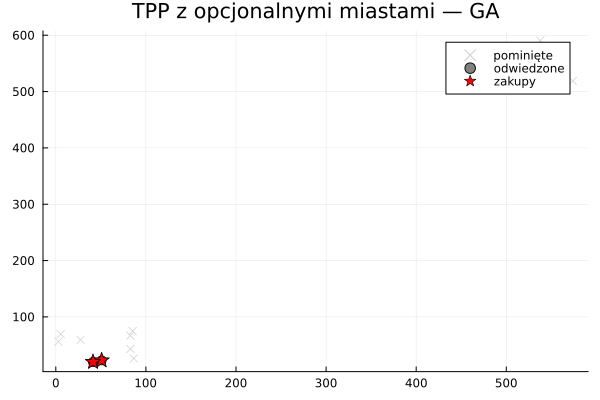

In [34]:
# Wizualizacja rozwiązania 5.0 — MIP optional
function plot_tpp_optional(X, Y, x_val, v_val, y_val; title_str="")
    n = size(x_val, 1)
    visited = [i for i in 1:n if v_val[i] > 0.5]
    skipped = [i for i in 1:n if v_val[i] <= 0.5]
    plt = Plots.scatter(X[skipped], Y[skipped]; label="pominięte",
                        color=:lightgray, ms=4, marker=:xcross,
                        legend=:topright, title=title_str)
    Plots.scatter!(plt, X[visited], Y[visited]; label="odwiedzone",
                   color=:gray, ms=5)
    for (i, j) in selected_edges(x_val, n)
        if i < j
            Plots.plot!(plt, [X[i], X[j]], [Y[i], Y[j]];
                        color=:steelblue, lw=2, label="")
        end
    end
    purchase_cities = unique([findfirst(>(0.5), y_val[p, :])
                              for p in 1:size(y_val, 1)])
    Plots.scatter!(plt, X[purchase_cities], Y[purchase_cities];
                   color=:red, ms=8, marker=:star5, label="zakupy")
    return plt
end

plot_tpp_optional(X_opt, Y_opt,
    JuMP.value.(model_opt[:x]), JuMP.value.(model_opt[:v]), JuMP.value.(model_opt[:y]);
    title_str="TPP z opcjonalnymi miastami — MIP")

plot_tpp_optional_ga(X_opt, Y_opt, sol_ga_optional, ci_opt;
    title_str="TPP z opcjonalnymi miastami — GA")


## Porównanie czterech podejść na instancji z opcjonalnymi miastami

Dla tej samej instancji uruchamiamy:
1. **MIP iteracyjny** dla wariantu z opcjonalnym odwiedzaniem miast.
2. **GA** dla wariantu z opcjonalnym odwiedzaniem miast.
3. **MIP** w wariancie z odwiedzaniem wszystkich miast.
4. **GA** w wariancie z odwiedzaniem wszystkich miast.

Dzięki temu porównujemy zarówno wpływ **modelu problemu** (miasta opcjonalne vs wszystkie miasta), jak i wpływ **metody rozwiązania** (MIP vs GA).


In [38]:
# Porównanie czterech podejść na tej samej instancji 5.0
t0 = time()
mip_visit_all_model, _, _, st_visit_all = solve_tpp_iterative(d_opt, ci_opt; verbose=false)
t_visit_all = time() - t0

t0 = time()
sol_ga_visit_all = run_ga_tpp(d_opt, ci_opt;
    pop_size=300, max_iters=600, time_limit=20.0, seed=99)
t_ga_visit_all = time() - t0

ga_opt_chrom = Evolutionary.minimizer(sol_ga_optional)
ga_opt_order, ga_opt_buy = split_optional_chromosome(ga_opt_chrom, n_opt, k_opt)
ga_opt_route = build_optional_route(ga_opt_order, ga_opt_buy)
ga_opt_visited = sort(unique(ga_opt_route))
ga_opt_skipped = setdiff(collect(1:n_opt), ga_opt_visited)

@printf("\nPorównanie na instancji n=%d, k=%d (3 miasta-przynęty):\n", n_opt, k_opt)
@printf("  MIP (opcjonalne miasta):           koszt = %.2f, czas = %.3f s, iter = %d\n",
    objective_value(model_opt), t_opt, it_opt)
@printf("  GA  (opcjonalne miasta):           koszt = %.2f, odwiedzone = %d, pominięte = %d\n",
    sol_ga_optional.minimum, length(ga_opt_visited), length(ga_opt_skipped))
@printf("  MIP (wszystkie miasta):            koszt = %.2f, czas = %.3f s, status = %s\n",
    objective_value(mip_visit_all_model), t_visit_all, String(st_visit_all))
@printf("  GA  (wszystkie miasta):            koszt = %.2f, czas = %.3f s\n",
    sol_ga_visit_all.minimum, t_ga_visit_all)



Porównanie na instancji n=12, k=6 (3 miasta-przynęty):
  MIP (opcjonalne miasta):           koszt = 459.01, czas = 0.001 s, iter = 0
  GA  (opcjonalne miasta):           koszt = 459.01, odwiedzone = 3, pominięte = 9
  MIP (wszystkie miasta):            koszt = 2004.15, czas = 0.007 s, status = optimal
  GA  (wszystkie miasta):            koszt = 2046.04, czas = 0.013 s


## Podsumowanie

* **Zad. 3.0** — zaimplementowano iteracyjną metodę MIP (`solve_tpp_iterative`) oraz algorytm genetyczny (`run_ga_tpp`) dla TPP z obowiązkowym odwiedzeniem wszystkich miast. Porównanie wykonano na 9 instancjach. Dla `n=50` MIP znajdował rozwiązania optymalne, natomiast dla `n=100` dwa z trzech przebiegów zakończyły się limitem czasu. GA we wszystkich przypadkach mieścił się w limicie minuty, ale zwracał rozwiązania wyraźnie gorsze jakościowo od MIP.
* **Zad. 4.0** — dodano składnik wagowy do funkcji kosztu w GA (`tpp_cost_weighted`) zgodnie z treścią zadania. Jakość rozwiązań należy porównywać w dwóch metrykach: bez wag (`plain`) oraz z wagami (`weighted`). Zaimplementowano także krzyżowanie PMX (`recombine_pmx`) i porównano je z krzyżowaniem opartym o inwersję.
* **Zad. 5.0** — zaimplementowano wariant z opcjonalnym odwiedzaniem miast (`build_tpp_model_optional`, `solve_tpp_optional`). W pokazanej instancji rozwiązanie odwiedza 3 miasta i pomija 9, więc spełnia warunek „odwiedza przynajmniej 3 miasta i omija przynajmniej 2”.
